# Osprey Pipeline Workflow

This notebook produces a comprehensive figure illustrating the four major phases of the
Osprey DIA analysis pipeline:

1. **Initialisation** — load library, generate decoys, build m/z index
2. **Calibration** — RT, MS1, and MS2 mass calibration from confident hits
3. **Coelution Search** — extract fragment XICs, detect peaks with CWT consensus
4. **Scoring & FDR** — extract 45 features per precursor, Percolator/Mokapot, output

The figure also includes small inline illustrations at each step to make it more
intuitive for a methods-section audience.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.gridspec import GridSpec

rng = np.random.default_rng(7)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'font.size': 9.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Standalone Workflow Diagram (publication-quality flow chart)

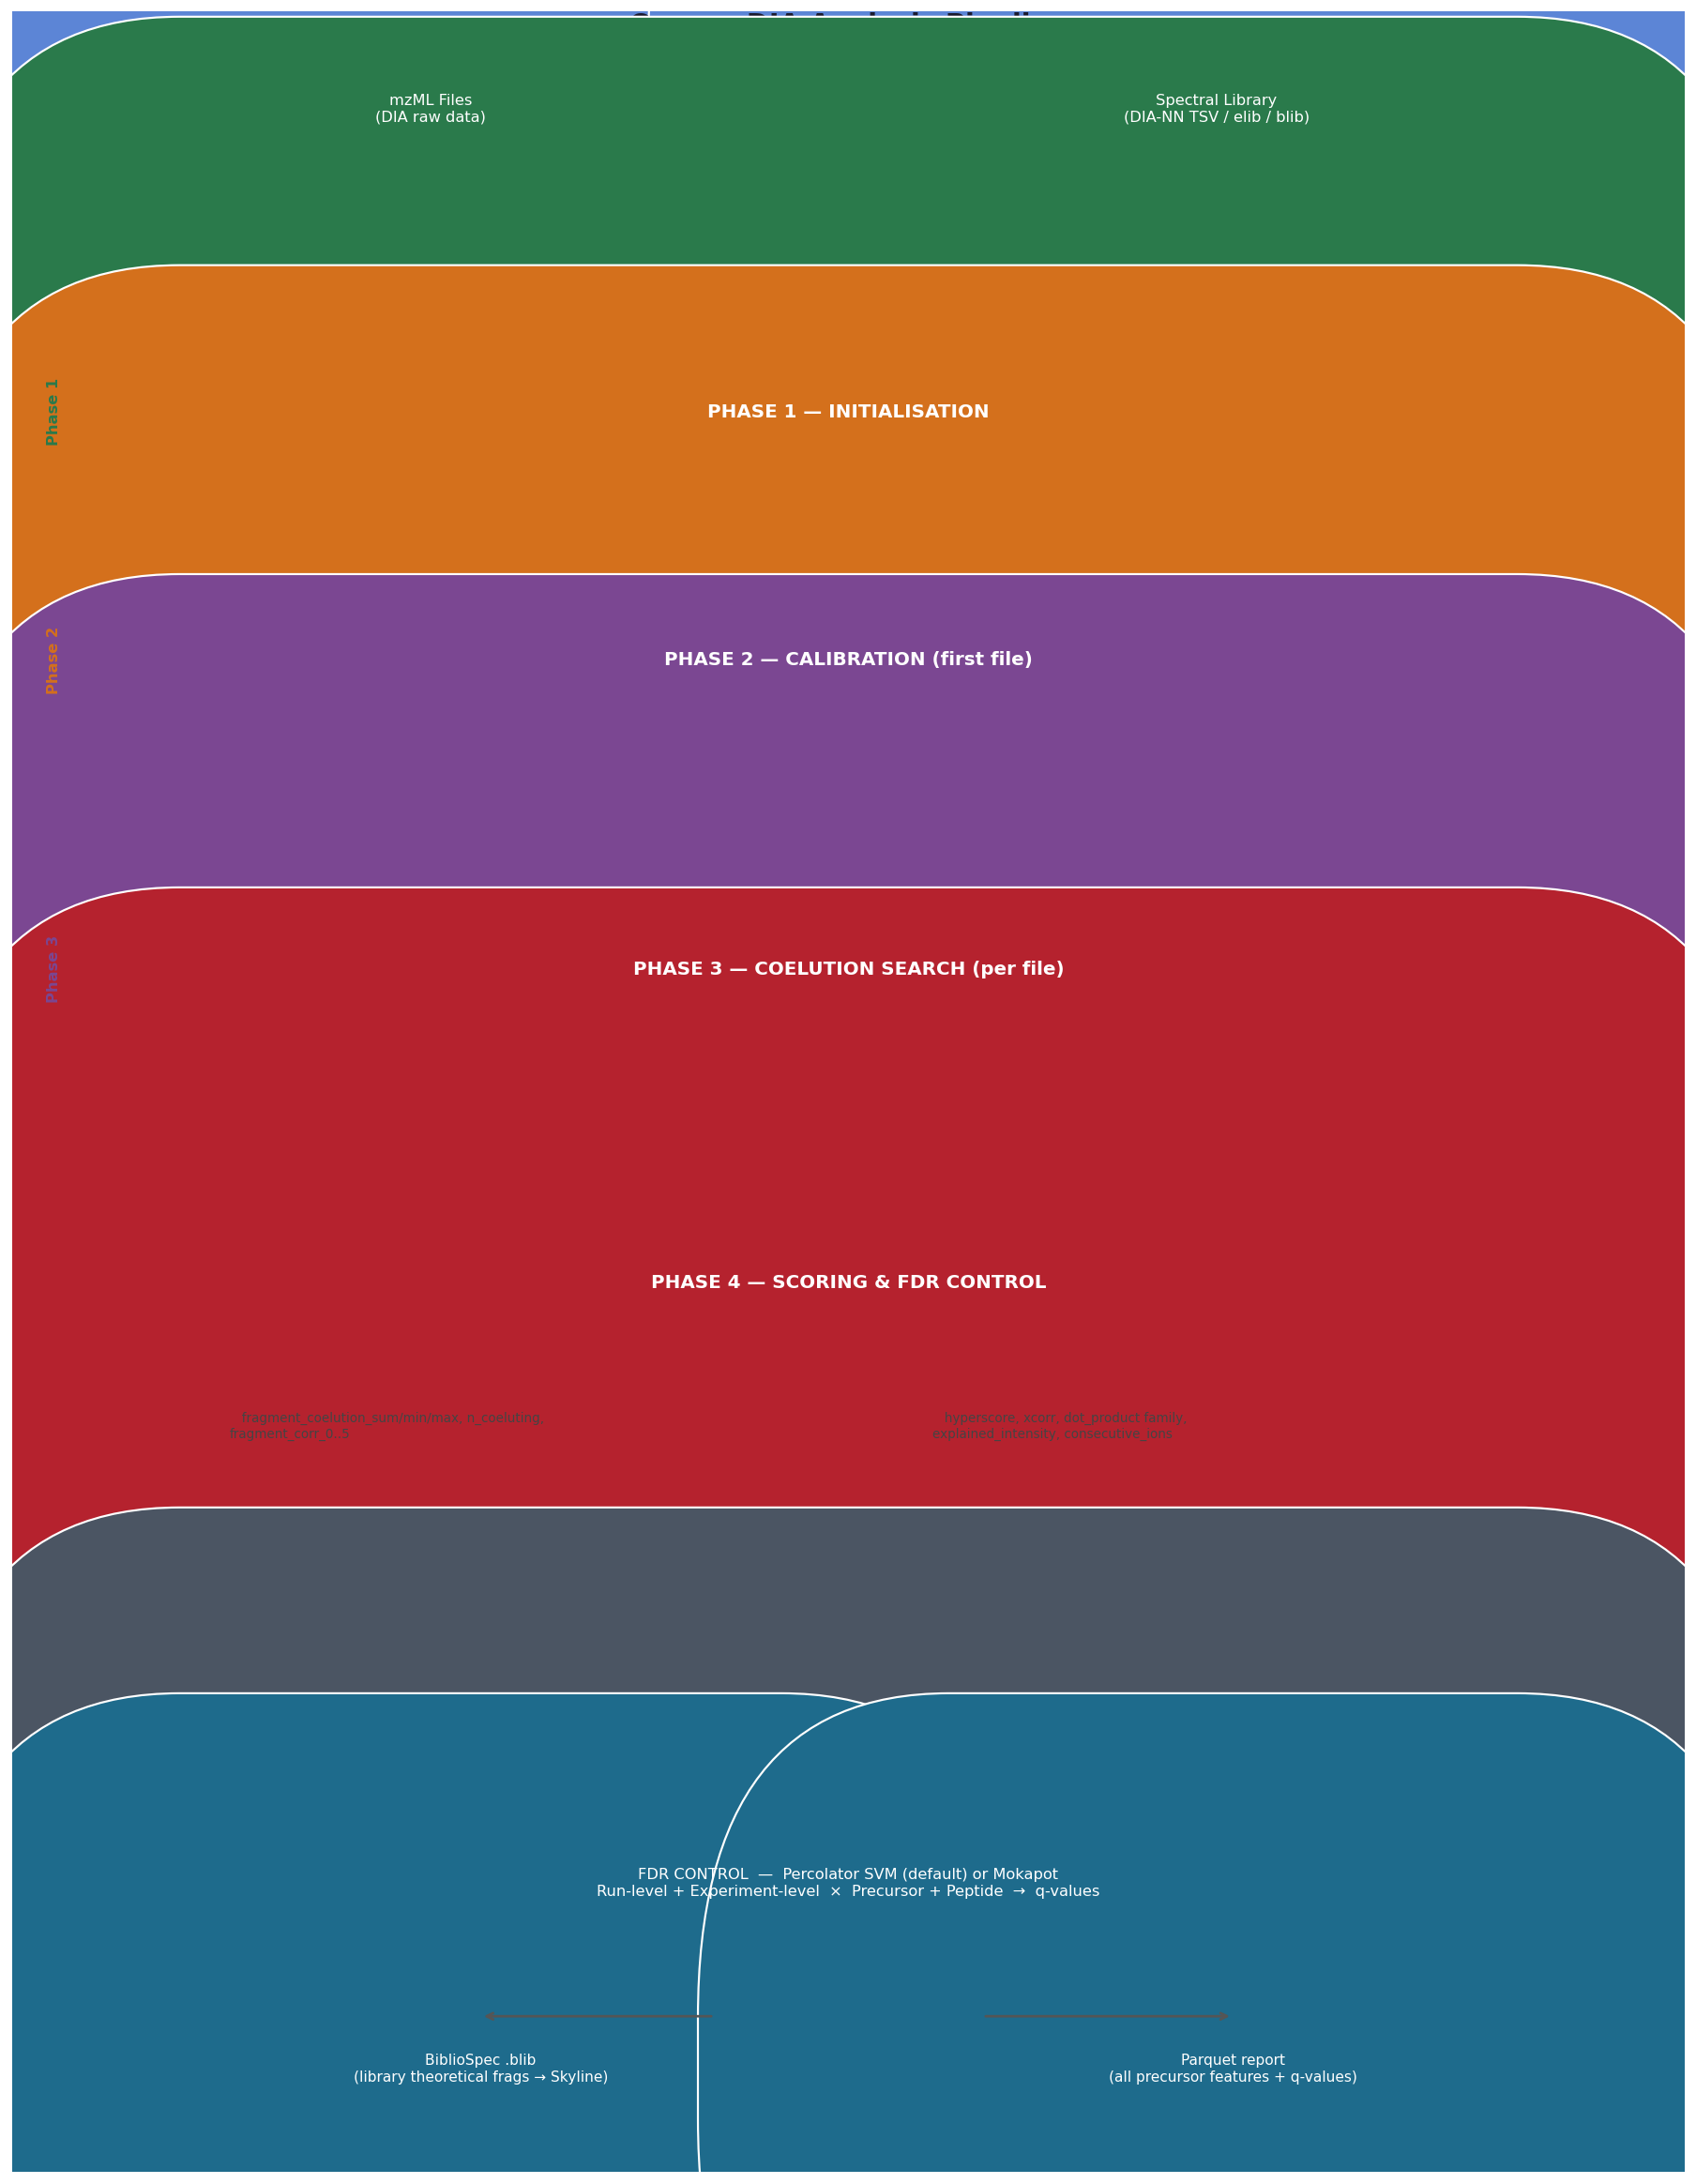

Saved: osprey_workflow.png


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper drawing utilities
# ─────────────────────────────────────────────────────────────────────────────

def draw_box(ax, x, y, width, height, text, color, text_color='white',
             fontsize=9.5, style='round,pad=0.15', bold=False):
    """Draw a rounded rectangle with centred text."""
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle=style, linewidth=1.2,
                         edgecolor='white', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=text_color,
            fontweight='bold' if bold else 'normal',
            wrap=True, zorder=4,
            multialignment='center')


def draw_arrow(ax, x1, y1, x2, y2, label='', color='#333333'):
    """Draw a thick arrow from (x1,y1) to (x2,y2)."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color=color),
                zorder=3)
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.02, my, label, ha='left', va='center',
                fontsize=8, color=color, style='italic')


def draw_bullet(ax, x, y, items, color, title=None, fontsize=8):
    """Draw a bulleted text block."""
    offset = 0.0
    if title:
        ax.text(x, y, title, ha='left', va='top', fontsize=fontsize,
                fontweight='bold', color=color)
        offset = 0.045
    for i, item in enumerate(items):
        ax.text(x, y - offset - i * 0.042, f'• {item}',
                ha='left', va='top', fontsize=fontsize-0.5, color='#333333')


# ─────────────────────────────────────────────────────────────────────────────
# Build the figure
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 18))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# ── Colour palette ─────────────────────────────────────────────────────────
C_INPUT  = '#5c85d6'
C_INIT   = '#2a7a4b'
C_CALIB  = '#d4701c'
C_SEARCH = '#7b4792'
C_SCORE  = '#b5222e'
C_OUTPUT = '#1e6b8c'
C_ARROW  = '#555555'

# ── INPUT boxes ────────────────────────────────────────────────────────────
draw_box(ax, 0.25, 0.955, 0.32, 0.05, 'mzML Files\n(DIA raw data)', C_INPUT, fontsize=9)
draw_box(ax, 0.72, 0.955, 0.38, 0.05, 'Spectral Library\n(DIA-NN TSV / elib / blib)', C_INPUT, fontsize=9)

ax.text(0.5, 1.0, 'Osprey DIA Analysis Pipeline', ha='center', va='top',
        fontsize=16, fontweight='bold', color='#1a1a2e')

# ── PHASE 1: INITIALISATION ────────────────────────────────────────────────
draw_arrow(ax, 0.25, 0.930, 0.25, 0.875, color=C_ARROW)
draw_arrow(ax, 0.72, 0.930, 0.72, 0.875, color=C_ARROW)
# Converge
ax.annotate('', xy=(0.50, 0.850), xytext=(0.25, 0.875),
            arrowprops=dict(arrowstyle='->', lw=1.8, color=C_ARROW))
ax.annotate('', xy=(0.50, 0.850), xytext=(0.72, 0.875),
            arrowprops=dict(arrowstyle='->', lw=1.8, color=C_ARROW))

draw_box(ax, 0.50, 0.815, 0.80, 0.065,
         'PHASE 1 — INITIALISATION', C_INIT, bold=True, fontsize=11)

draw_bullet(ax, 0.125, 0.785,
    ['Deduplicate library by (sequence, charge)',
     'Generate enzyme-aware decoys (sequence reversal)',
     'Build m/z index for candidate lookup (sorted bins)',
     'Load all mzML spectra + build MS1 index'],
    C_INIT, fontsize=8.5)

# ── PHASE 2: CALIBRATION ───────────────────────────────────────────────────
draw_arrow(ax, 0.50, 0.782, 0.50, 0.735, color=C_ARROW)

draw_box(ax, 0.50, 0.700, 0.80, 0.065,
         'PHASE 2 — CALIBRATION (first file)', C_CALIB, bold=True, fontsize=11)

draw_bullet(ax, 0.125, 0.670,
    ['Wide RT window → XCorr + E-value scoring vs all spectra',
     'Target-decoy competition at 1% FDR → confident hits',
     'Fit LOESS RT calibration (library RT → measured RT)',
     'Compute MS1 + MS2 mass error histograms',
     'Extract σ of mass errors → tight RT + m/z tolerances for main search'],
    C_CALIB, fontsize=8.5)

# ── PHASE 3: COELUTION SEARCH ──────────────────────────────────────────────
draw_arrow(ax, 0.50, 0.638, 0.50, 0.590, color=C_ARROW)

draw_box(ax, 0.50, 0.557, 0.80, 0.065,
         'PHASE 3 — COELUTION SEARCH (per file)', C_SEARCH, bold=True, fontsize=11)

draw_bullet(ax, 0.125, 0.525,
    ['For each candidate precursor: extract fragment XICs within RT window',
     'CWT consensus peak detection (Mexican Hat wavelet, median across fragments)',
     'Valley-guarded ±2σ boundary extension → integration window',
     'Fallback if CWT fails: median polish profile → reference XIC'],
    C_SEARCH, fontsize=8.5)

# ── PHASE 4: SCORING & FDR ─────────────────────────────────────────────────
draw_arrow(ax, 0.50, 0.494, 0.50, 0.445, color=C_ARROW)

draw_box(ax, 0.50, 0.412, 0.80, 0.065,
         'PHASE 4 — SCORING & FDR CONTROL', C_SCORE, bold=True, fontsize=11)

# Feature groups (two columns)
group1 = [
    ('Pairwise coelution (11)', 'fragment_coelution_sum/min/max, n_coeluting,\nfragment_corr_0..5'),
    ('Peak shape (7)', 'peak_apex, peak_area, peak_width,\npeak_symmetry, SNR, n_scans, sharpness'),
    ('Mass accuracy (3)', 'mean signed/abs error, std (ppm or Th)'),
]
group2 = [
    ('Spectral at apex (15)', 'hyperscore, xcorr, dot_product family,\nexplained_intensity, consecutive_ions'),
    ('Elution cosine (1)', 'elution_weighted_cosine (coef²-weighted)'),
    ('Median polish (3)', 'mp_cosine, mp_R², mp_residual_ratio'),
    ('Peptide props (5)', 'rt_deviation, length, missed_cleavages,\nln_candidates, ms1_coelution'),
]

y0 = 0.375
for i, (title, desc) in enumerate(group1):
    y = y0 - i * 0.058
    ax.text(0.13, y, f'▸ {title}', ha='left', va='top', fontsize=8.5,
            fontweight='bold', color=C_SCORE)
    ax.text(0.13, y - 0.023, f'   {desc}', ha='left', va='top', fontsize=7.5, color='#444')

for i, (title, desc) in enumerate(group2):
    y = y0 - i * 0.058
    ax.text(0.55, y, f'▸ {title}', ha='left', va='top', fontsize=8.5,
            fontweight='bold', color=C_SCORE)
    ax.text(0.55, y - 0.023, f'   {desc}', ha='left', va='top', fontsize=7.5, color='#444')

ax.text(0.13, y0 - 3*0.058, '→ 45 features total per precursor candidate',
        ha='left', va='top', fontsize=8.5, fontweight='bold', color='#1a1a2e')

# FDR box
draw_arrow(ax, 0.50, 0.197, 0.50, 0.158, color=C_ARROW)

draw_box(ax, 0.50, 0.134, 0.80, 0.047,
         'FDR CONTROL  —  Percolator SVM (default) or Mokapot\n'
         'Run-level + Experiment-level  ×  Precursor + Peptide  →  q-values',
         '#4b5563', fontsize=9)

# ── OUTPUT ─────────────────────────────────────────────────────────────────
draw_arrow(ax, 0.50, 0.110, 0.50, 0.075, color=C_ARROW)

draw_box(ax, 0.28, 0.048, 0.36, 0.047,
         'BiblioSpec .blib\n(library theoretical frags → Skyline)', C_OUTPUT, fontsize=8.5)
draw_box(ax, 0.73, 0.048, 0.34, 0.047,
         'Parquet report\n(all precursor features + q-values)', C_OUTPUT, fontsize=8.5)

ax.annotate('', xy=(0.28, 0.072), xytext=(0.42, 0.072),
            arrowprops=dict(arrowstyle='->', lw=1.5, color=C_ARROW))
ax.annotate('', xy=(0.73, 0.072), xytext=(0.58, 0.072),
            arrowprops=dict(arrowstyle='->', lw=1.5, color=C_ARROW))

# Phase labels on left margin
for y, label, c in [
    (0.815, 'Phase 1', C_INIT),
    (0.700, 'Phase 2', C_CALIB),
    (0.557, 'Phase 3', C_SEARCH),
    (0.412, 'Phase 4', C_SCORE),
]:
    ax.text(0.025, y, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color=c, rotation=90)

plt.tight_layout()
plt.savefig('osprey_workflow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: osprey_workflow.png')

## 2. Data Flow — Annotated Example with Synthetic Data

The following multi-panel figure shows what the data actually looks like at each step
for a single precursor.

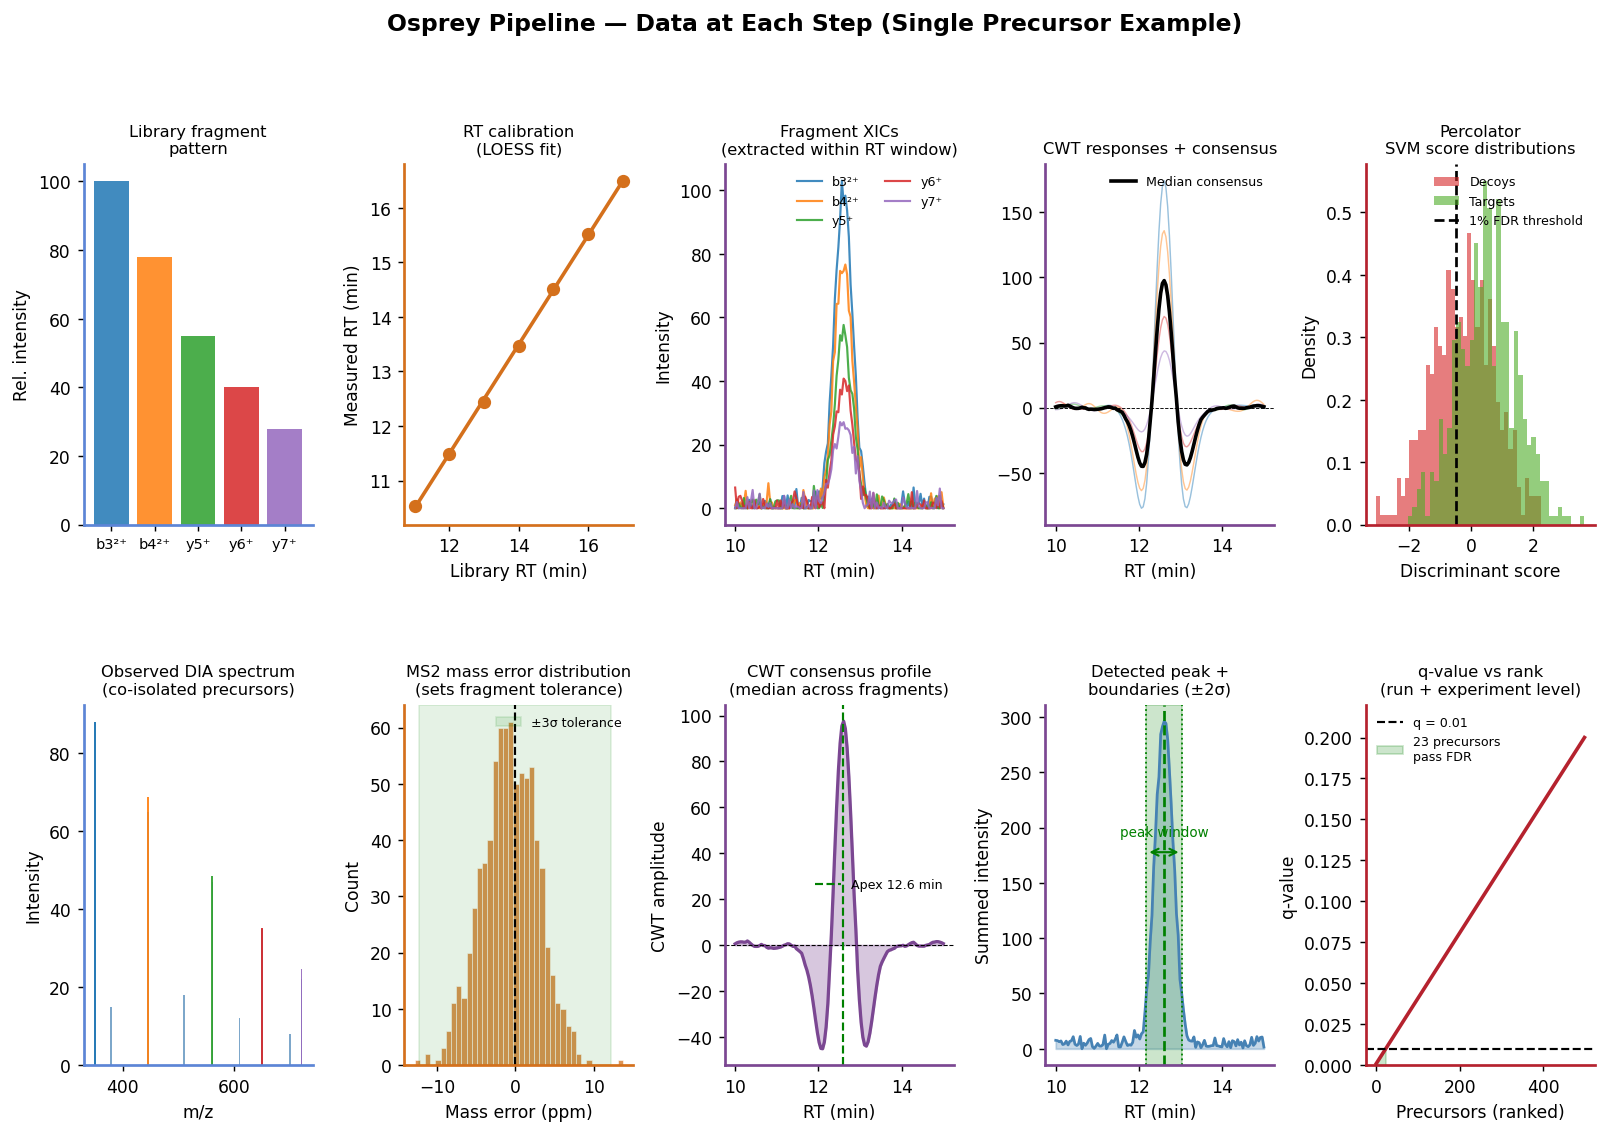

Saved: osprey_workflow_data.png


In [4]:
def gaussian(rt, apex, h, s):
    return h * np.exp(-0.5 * ((rt - apex) / s) ** 2)

rt = np.linspace(10, 15, 120)
lib_ints = np.array([100, 78, 55, 40, 28], dtype=float)
frag_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
frag_labels = ['b3²⁺', 'b4²⁺', 'y5⁺', 'y6⁺', 'y7⁺']
apex_rt, peak_s = 12.6, 0.22
noise_s = 2.5

xics = [gaussian(rt, apex_rt, li, peak_s) + rng.normal(0, noise_s, len(rt))
        for li in lib_ints]
xics = [np.clip(x, 0, None) for x in xics]

# CWT consensus elution profile (used for peak boundary detection)
from scipy.signal import convolve as sp_convolve

def mex_hat(sigma=5, radius=None):
    if radius is None:
        radius = int(np.ceil(5 * sigma))
    t = np.arange(-radius, radius + 1, dtype=float)
    norm = 2 / (np.sqrt(3 * sigma) * np.pi**0.25)
    k = norm * (1 - (t/sigma)**2) * np.exp(-t**2/(2*sigma**2))
    k -= k.mean()
    return k

scan_width = rt[1] - rt[0]
sigma_scans = max(2.0, min(20.0, peak_s / scan_width))
kernel = mex_hat(sigma_scans)
cwt_per_frag = [sp_convolve(xic, kernel, mode='same') for xic in xics]
consensus = np.median(np.stack(cwt_per_frag), axis=0)

# Simulated calibration: library RT 13.1 min → measured 12.6 min
lib_rts  = np.array([11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0])
meas_rts = lib_rts - 0.5 + rng.normal(0, 0.04, len(lib_rts))

# PIN score distribution
n_target = 500
n_decoy  = 500
scores_target = rng.normal( 0.5, 1.0, n_target)
scores_decoy  = rng.normal(-0.3, 1.0, n_decoy)

# Simulated q-values
q_threshold = 0.01

# ── Build 5-panel figure ───────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))
gs  = GridSpec(2, 5, figure=fig, hspace=0.50, wspace=0.40)

axes_top = [fig.add_subplot(gs[0, i]) for i in range(5)]
axes_bot = [fig.add_subplot(gs[1, i]) for i in range(5)]

# ── Panel A (top): Library bar-chart ──────────────────────────────────────
ax = axes_top[0]
ax.bar(range(len(lib_ints)), lib_ints, color=frag_colors, alpha=0.85)
ax.set_xticks(range(len(lib_ints)))
ax.set_xticklabels(frag_labels, fontsize=8)
ax.set_ylabel('Rel. intensity')
ax.set_title('Library fragment\npattern', fontsize=9)

# ── Panel A (bottom): Example "mixed" DIA spectrum ─────────────────────────
ax = axes_bot[0]
mzs = np.array([350, 445, 560, 650, 720, 380, 510, 610, 700]) + rng.uniform(-1, 1, 9)
ints_obs = np.array([88, 65, 47, 35, 22, 15, 18, 12, 8], dtype=float)
ax.bar(mzs, ints_obs, width=3, color='steelblue', alpha=0.7)
for mz_target, li, c in zip([350, 445, 560, 650, 720], lib_ints, frag_colors):
    ax.bar(mz_target, li * 0.88, width=3, color=c, alpha=0.9)
ax.set_xlabel('m/z')
ax.set_ylabel('Intensity')
ax.set_title('Observed DIA spectrum\n(co-isolated precursors)', fontsize=9)

# ── Panel B (top): RT calibration curve ───────────────────────────────────
ax = axes_top[1]
ax.scatter(lib_rts, meas_rts, color=C_CALIB, s=40, zorder=4)
p = np.polyfit(lib_rts, meas_rts, 1)
rt_line = np.linspace(lib_rts[0], lib_rts[-1], 100)
ax.plot(rt_line, np.polyval(p, rt_line), color=C_CALIB, lw=2)
ax.set_xlabel('Library RT (min)')
ax.set_ylabel('Measured RT (min)')
ax.set_title('RT calibration\n(LOESS fit)', fontsize=9)

# ── Panel B (bottom): Mass error histogram ─────────────────────────────────
ax = axes_bot[1]
mass_errors_ppm = rng.normal(-0.5, 3.5, 800)
ax.hist(mass_errors_ppm, bins=40, color=C_CALIB, alpha=0.75, edgecolor='white', lw=0.4)
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.axvspan(-3.5*3.5, 3.5*3.5, alpha=0.1, color='green', label='±3σ tolerance')
ax.set_xlabel('Mass error (ppm)')
ax.set_ylabel('Count')
ax.set_title('MS2 mass error distribution\n(sets fragment tolerance)', fontsize=9)
ax.legend(fontsize=7, frameon=False)

# ── Panel C (top): Fragment XICs ──────────────────────────────────────────
ax = axes_top[2]
for xic, color, label in zip(xics, frag_colors, frag_labels):
    ax.plot(rt, xic, color=color, lw=1.2, label=label, alpha=0.85)
ax.set_xlabel('RT (min)')
ax.set_ylabel('Intensity')
ax.set_title('Fragment XICs\n(extracted within RT window)', fontsize=9)
ax.legend(fontsize=7, ncol=2, frameon=False)

# ── Panel C (bottom): CWT consensus profile ───────────────────────────────
ax = axes_bot[2]
ax.fill_between(rt, consensus, alpha=0.3, color=C_SEARCH)
ax.plot(rt, consensus, color=C_SEARCH, lw=1.8)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axvline(apex_rt, color='green', lw=1.2, ls='--', label=f'Apex {apex_rt:.1f} min')
ax.set_xlabel('RT (min)')
ax.set_ylabel('CWT amplitude')
ax.set_title('CWT consensus profile\n(median across fragments)', fontsize=9)
ax.legend(fontsize=7, frameon=False)

# ── Panel D (top): CWT per-fragment responses ─────────────────────────────
ax = axes_top[3]
for coeff, color in zip(cwt_per_frag, frag_colors):
    ax.plot(rt, coeff, color=color, lw=0.8, alpha=0.45)
ax.plot(rt, consensus, color='black', lw=2, label='Median consensus', zorder=5)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_xlabel('RT (min)')
ax.set_title('CWT responses + consensus', fontsize=9)
ax.legend(fontsize=7, frameon=False)

# ── Panel D (bottom): Peak boundaries on reference ────────────────────────
ax = axes_bot[3]
ref = np.stack(xics).sum(axis=0)
ax.fill_between(rt, ref, alpha=0.3, color='steelblue')
ax.plot(rt, ref, color='steelblue', lw=1.5)

bnd_start = apex_rt - 2 * peak_s
bnd_end   = apex_rt + 2 * peak_s
ax.axvspan(bnd_start, bnd_end, alpha=0.2, color='green')
ax.axvline(apex_rt, color='green', lw=1.5, ls='--')
ax.axvline(bnd_start, color='green', lw=1.0, ls=':')
ax.axvline(bnd_end,   color='green', lw=1.0, ls=':')
ax.annotate('', xy=(bnd_end, ref.max() * 0.6), xytext=(bnd_start, ref.max() * 0.6),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.2))
ax.text(apex_rt, ref.max() * 0.65, 'peak window',
        ha='center', fontsize=7.5, color='green')
ax.set_xlabel('RT (min)')
ax.set_ylabel('Summed intensity')
ax.set_title('Detected peak +\nboundaries (±2σ)', fontsize=9)

# ── Panel E (top): Score distributions ────────────────────────────────────
ax = axes_top[4]
ax.hist(scores_decoy,  bins=40, alpha=0.6, color='#d62728', label='Decoys',  density=True)
ax.hist(scores_target, bins=40, alpha=0.6, color='#4dac26', label='Targets', density=True)
ax.axvline(np.percentile(scores_target, 15), color='black', lw=1.5, ls='--',
           label='1% FDR threshold')
ax.set_xlabel('Discriminant score')
ax.set_ylabel('Density')
ax.set_title('Percolator\nSVM score distributions', fontsize=9)
ax.legend(fontsize=7, frameon=False)

# ── Panel E (bottom): q-value cascade ────────────────────────────────────
ax = axes_bot[4]
scores_sorted = np.sort(scores_target)[::-1]
q_approx = np.linspace(0.001, 0.20, len(scores_sorted))
ids_pass = np.searchsorted(q_approx, q_threshold)

ax.plot(np.arange(len(scores_sorted)), q_approx, color=C_SCORE, lw=2)
ax.axhline(q_threshold, color='black', lw=1.2, ls='--', label=f'q = {q_threshold}')
ax.fill_between(np.arange(ids_pass), q_approx[:ids_pass],
                alpha=0.2, color='green', label=f'{ids_pass} precursors\npass FDR')
ax.set_xlabel('Precursors (ranked)')
ax.set_ylabel('q-value')
ax.set_title('q-value vs rank\n(run + experiment level)', fontsize=9)
ax.set_ylim(0, 0.22)
ax.legend(fontsize=7, frameon=False)

# ── Phase panel labels ──────────────────────────────────────────────────────
phase_map = [
    (0, 'Input', C_INPUT),
    (1, 'Phase 2\nCalibration', C_CALIB),
    (2, 'Phase 3\nSearch', C_SEARCH),
    (3, 'Phase 3\nCWT', C_SEARCH),
    (4, 'Phase 4\nFDR', C_SCORE),
]
for col_i, phase_label, c in phase_map:
    for row_ax in [axes_top[col_i], axes_bot[col_i]]:
        for spine in row_ax.spines.values():
            spine.set_edgecolor(c)
            spine.set_linewidth(1.5)

fig.suptitle('Osprey Pipeline — Data at Each Step (Single Precursor Example)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('osprey_workflow_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: osprey_workflow_data.png')
